# QuSpin ZXZ Y - rdm tensor network factorization

Created: 12-06-2026

Objectives:

In the [previous notebook](quspin_zxz_y_defects.ipynb), we encountered issues with the wavefunctions of the purifications being long range entangled. I think we can get around this by employing a [tensor network factorization](https://quimb.readthedocs.io/en/latest/examples/ex_tn_tensor_fitting.html).

1. Find $\rho$.
2. Find a tensor network factorization of $\rho$.
3. Extract resulting purified states.
4. Check schmidt decomposition, short range entangled.

We will use a Hamiltonian of the form $\sum_i (-t*Z_{i-1}X_i Z_{i+1} -(1-t)*Y)$ to test this, which has an $XK$ time reversal symmetry.

# Imports

In [1]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
from tqdm import tqdm

In [4]:
from functools import reduce

In [5]:
import quimb.tensor as qtn
import quimb as qu

# Analysis

## Find grounstate

In [6]:
num_sites = 16

In [7]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [8]:
# Use periodic boundary conditions.
def get_hamiltoniain(t, L=10):
    static = [
        ["zxz", [[-t, i, (i+1)%L, (i+2)%L] for i in range(L)]],
        ["y", [[-(1-t), i] for i in range(L)]],
    ]
    dynamic = []

    basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)
    out = hamiltonian(
        static,
        [],
        basis=basis,
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )

    return out

In [9]:
parameter = 0.75

In [10]:
hamiltonian = get_hamiltoniain(parameter, num_sites)

In [11]:
e, psi = hamiltonian.eigsh(k=1, which='SA')

In [12]:
e

array([-12.2250629])

## Find $\rho$

In [13]:
symmetry_sites = list(range(4, 12))

num_symmetry_sites = len(symmetry_sites)

In [14]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [15]:
rho = basis.partial_trace(
    psi,
    sub_sys_A=symmetry_sites,
    return_rdm="A",
    enforce_pure=True
)

## Set up optimization

In [16]:
rho.shape

(256, 256)

In [17]:
rho_reshaped = rho.reshape((16, 16, 16, 16,))

In [18]:
qt_rho = qtn.Tensor(
    data=rho_reshaped,
    inds=('lk', 'rk', 'lb', 'rb')
)

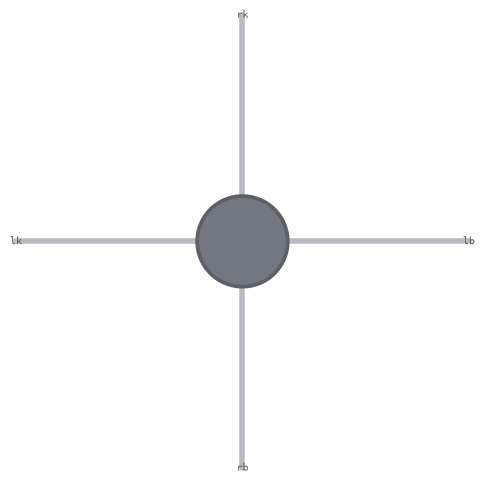

In [19]:
qt_rho.draw()

In [20]:
qt_rho.norm()

np.float64(0.49995259495669864)

In [21]:
np.trace(rho)

np.complex128(0.9999999999999994+0j)

In [22]:
horiztonal_bond_dimension = 16
vertical_bond_dimension = 4

In [23]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [24]:
A_left = qtn.Tensor(
    data=random_uniform_complex((vertical_bond_dimension, 2**4, horiztonal_bond_dimension)),
    inds=('vLV', 'kl', 'vH')
)

A_right = qtn.Tensor(
    data=random_uniform_complex((horiztonal_bond_dimension, 2**4, vertical_bond_dimension)),
    inds=('vH', 'kr', 'vRV')
)

In [25]:
rho_purity = np.trace(rho @ rho)

In [26]:
rho_purity

np.complex128(0.2499525972039368+2.0344948763841083e-20j)

In [27]:
rho_purity = np.real(rho_purity)

In [28]:
A = qtn.TensorNetwork([A_left, A_right])

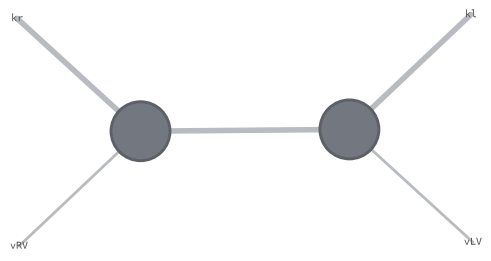

In [29]:
A.draw()

In [30]:
def get_rho_A(A):
    A_bottom = A.conj().reindex({'kl': 'bl', 'kr': 'br'})
    return A & A_bottom

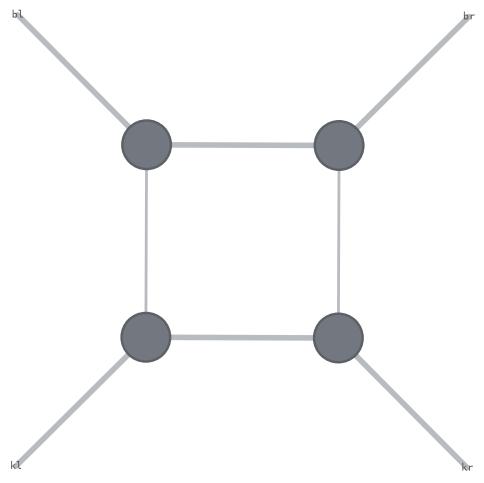

In [31]:
get_rho_A(A).draw()

In [32]:
rho_A = get_rho_A(A)

In [33]:
def rho_A_trace(rho_A):
    out = (
        rho_A
        .reindex({'bl': 'kl', 'br': 'kr'})
        .contract()
    )
    return out

In [34]:
rho_A_trace(rho_A)

np.complex128(285813.699595689-9.094947017729282e-13j)

In [35]:
rho_A_trace(rho_A/2)

np.complex128(142906.84979784445-4.547473508864641e-13j)

In [36]:
rho_A_trace(rho_A.multiply(0.5))

np.complex128(142906.84979784445-4.547473508864641e-13j)

In [37]:
rho_A_trace(rho_A.multiply(0.5))**(-1)

np.complex128(6.99756520708837e-06+2.226712187050621e-23j)

In [38]:
def normalize_rho_A(rho_A):
    trace = rho_A_trace(rho_A)
    return rho_A.multiply(trace**(-1))

In [39]:
tn = (
    (rho_A.reindex({'bl': 'kl', 'br': 'kr'}))
    & rho_A
)

In [40]:
transpose_reindex_dict = {
    'bl': 'kl',
    'br': 'kr',
    'kl': 'bl',
    'kr': 'br'
}

In [41]:
def rho_A_purity(rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho_A
    )

    out = tn.contract()

    return out

In [42]:
rho_A_purity(rho_A)

np.complex128(76847606032.34683+0j)

In [43]:
def rho_A_rho_overlap(rho, rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho
    )

    out = tn.contract()

    return out

In [44]:
rho.shape

(256, 256)

In [45]:
qu_rho = qtn.Tensor(
    data=rho.reshape(16, 16, 16, 16),
    inds=('kl', 'kr', 'bl', 'br')
)

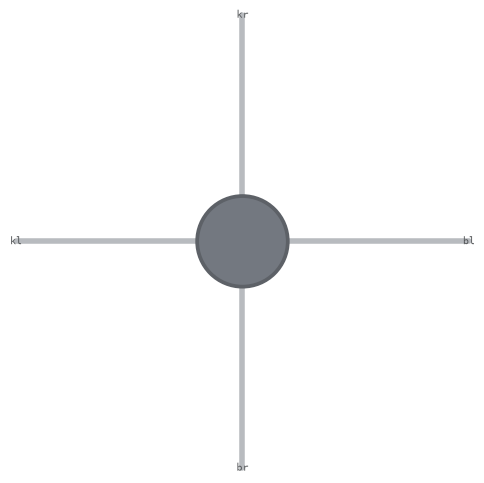

In [46]:
qu_rho.draw()

In [47]:
def loss_func(A, rho):
    rho_A = get_rho_A(A)

    out = np.real(
        rho_purity
        + rho_A_purity(rho_A)
        -2*rho_A_rho_overlap(rho, rho_A)
    )

    return out

In [48]:
rho_A = normalize_rho_A(rho_A)

In [49]:
def normalize_A(A):
    rho_A = get_rho_A(A)
    trace = rho_A_trace(rho_A)
    return A.multiply(trace**(-0.5))

In [50]:
tnopt = qtn.TNOptimizer(
    A,  # the tensor network we want to optimize
    loss_func,  # the function we want to minimize
    norm_fn=normalize_A,
    loss_constants={"rho": qu_rho},  # supply U to the loss function as a constant TN
    autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
    optimizer="L-BFGS-B",  # the optimization algorithm
)

In [51]:
A_opt = tnopt.optimize_basinhopping(n=100,  nhop=5)

  0%|                                                                                                                        | 0/500 [00:00<?, ?it/s]/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(
+0.004625499249 [best: +0.004372954369] :   5%|███▏                                                                 | 23/500 [00:00<00:15, 30.91it/s]


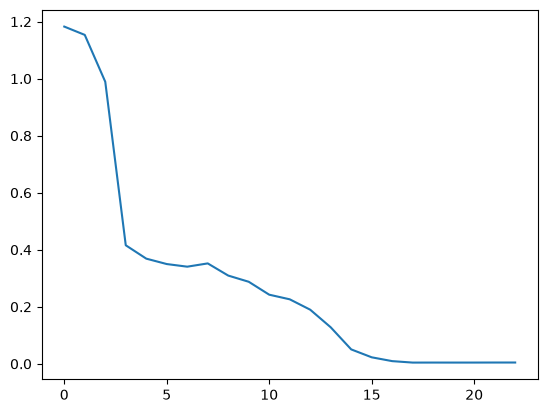

In [52]:
plt.plot(tnopt.losses)

In [53]:
tnopt.loss_best

0.004372954368591309

In [54]:
A_opt

TensorNetwork(tensors=2, indices=5)

In [55]:
A_l_opt = A_opt.tensors[0]

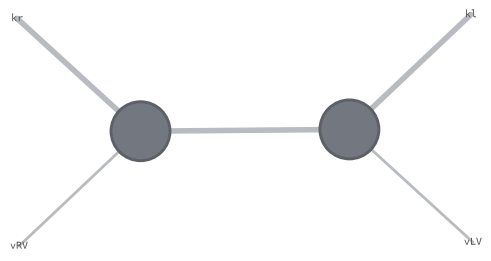

In [56]:
A_opt.draw()

### Check the output rho is accurate

In [57]:
rho_A_opt = get_rho_A(A_opt)

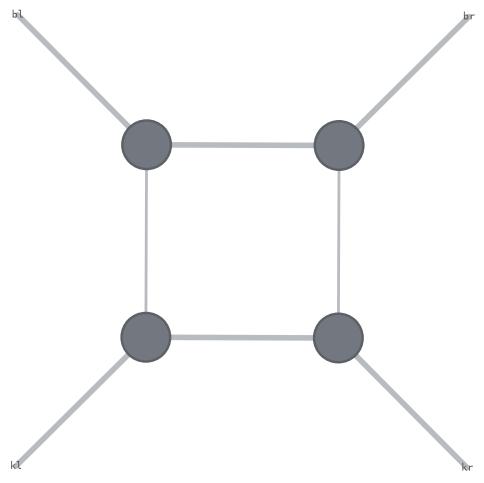

In [58]:
rho_A_opt.draw()

In [59]:
qu_rho

Tensor(shape=(16, 16, 16, 16), inds=('kl', 'kr', 'bl', 'br'), tags=oset([]))

In [60]:
rho_A_opt.contract()

Tensor(shape=(16, 16, 16, 16), inds=('kl', 'kr', 'bl', 'br'), tags=oset([]))

In [61]:
diff_rho_opt = qu_rho - rho_A_opt.contract()

In [62]:
(diff_rho_opt & diff_rho_opt.conj()).contract()

np.complex128(0.004372974601397309+0j)

Looks good.

## Restructure $A$ tensors to have a schmidt decomposition

In [63]:
tn_l = (
    A_l_opt
    &
    A_l_opt.conj().reindex({'kl': 'bl', 'vH': 'vBH'})
)

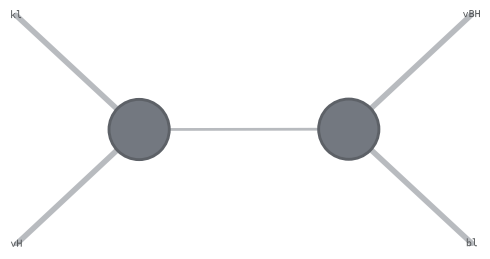

In [64]:
tn_l.draw()

In [65]:
tn_l = tn_l.contract()

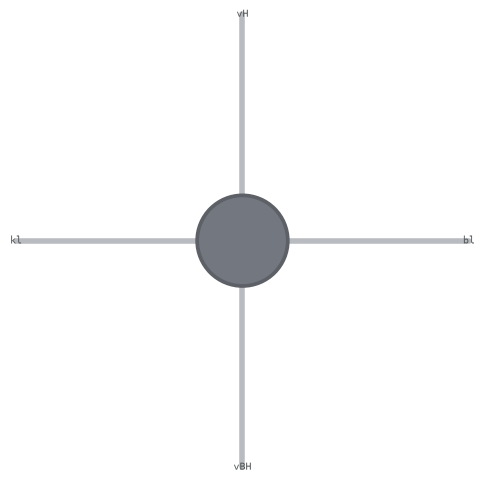

In [66]:
tn_l.draw()

In [67]:
left_eig_out = qtn.tensor_core.tensor_split(
    tn_l,
    left_inds=['kl', 'vH'],
    method='svd',
    #cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vLV'
)

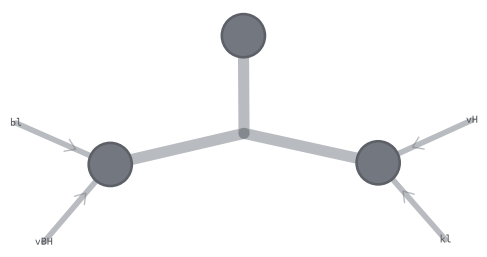

In [68]:
left_eig_out.draw()

In [69]:
left_eig_out.tensors[1].data

array([5.66670179e-01, 5.48215508e-01, 5.78357950e-02, 3.73835154e-02,
       2.70209398e-07, 2.49262655e-07, 1.87536443e-07, 1.69208079e-07,
       1.66516784e-07, 1.60073469e-07, 1.35843464e-07, 1.34994906e-07,
       1.29746823e-07, 1.23540815e-07, 1.22385813e-07, 1.02712505e-07,
       1.00701776e-07, 9.48713250e-08, 9.12551315e-08, 8.51335642e-08,
       8.38790797e-08, 7.88969032e-08, 7.06291061e-08, 6.53519265e-08,
       5.84892952e-08, 5.13056442e-08, 4.29075619e-08, 4.14121963e-08,
       3.55334286e-08, 3.30360663e-08, 3.30360663e-08, 3.30360663e-08,
       3.30360663e-08, 3.30360663e-08, 3.30360663e-08, 3.30360663e-08,
       3.30360663e-08, 3.30360663e-08, 3.30360663e-08, 3.30360663e-08,
       3.30360663e-08, 3.30360663e-08, 3.30360663e-08, 3.30360663e-08,
       3.30360663e-08, 3.30360663e-08, 3.30360663e-08, 3.30360663e-08,
       3.30360663e-08, 3.30360663e-08, 3.30360663e-08, 3.30360663e-08,
       3.30360663e-08, 3.30360663e-08, 3.30360663e-08, 3.30360663e-08,
      

In [70]:
diff = (left_eig_out.contract(output_inds=tn_l.contract().inds) - tn_l.contract())

In [71]:
(diff & diff.conj()).contract()

np.complex64(7.142974e-13+0j)

In [72]:
A_r_opt = A_opt.tensors[1]

In [73]:
tn_r = (
    A_r_opt
    &
    A_r_opt.conj().reindex({'kr': 'br', 'vH': 'vBH'})
)

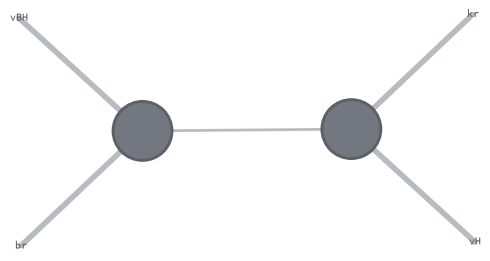

In [74]:
tn_r.draw()

In [75]:
tn_r = tn_r.contract()

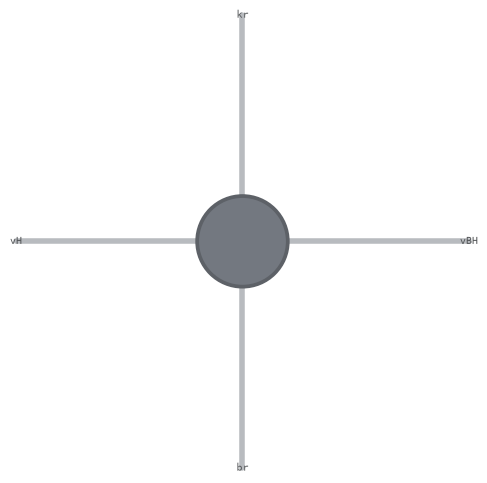

In [76]:
tn_r.draw()

Check `tn_r` is Hermitian.

In [77]:
X = tn_r.data.reshape((256, 256))

In [78]:
np.linalg.norm(X - X.T.conj())

np.float32(4.885808e-08)

So yes, Hermitian.

In [79]:
right_eig_out = qtn.tensor_core.tensor_split(
    tn_r,
    left_inds=['kr', 'vH'],
    method='svd',
    #cutoff=1e-3,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vRV'
)

In [80]:
right_eig_out

TensorNetwork(tensors=3, indices=5)

In [81]:
right_eig_out.tensors[1].data

array([9.1912830e-01, 8.5305458e-01, 1.3270111e-01, 6.2510654e-02,
       2.5973847e-07, 2.2003549e-07, 2.1843398e-07, 1.8822371e-07,
       1.8695279e-07, 1.7120405e-07, 1.6368969e-07, 1.4724456e-07,
       1.4179273e-07, 1.3488227e-07, 1.3063985e-07, 1.2342571e-07,
       1.2308121e-07, 1.1692594e-07, 1.1412167e-07, 1.0354457e-07,
       8.9408282e-08, 8.2027675e-08, 7.4474613e-08, 7.1473615e-08,
       5.8823762e-08, 5.7461008e-08, 5.0689341e-08, 5.0689341e-08,
       5.0689341e-08, 5.0689341e-08, 5.0689341e-08, 5.0689341e-08,
       5.0689341e-08, 5.0689341e-08, 5.0689341e-08, 5.0689341e-08,
       5.0689341e-08, 5.0689341e-08, 5.0689341e-08, 5.0689341e-08,
       5.0689341e-08, 5.0689341e-08, 5.0689341e-08, 5.0689341e-08,
       5.0689341e-08, 5.0689341e-08, 5.0689341e-08, 5.0689341e-08,
       5.0689341e-08, 5.0689341e-08, 5.0689341e-08, 5.0689341e-08,
       5.0689341e-08, 5.0689341e-08, 5.0689341e-08, 5.0689341e-08,
       5.0689341e-08, 5.0689341e-08, 5.0689341e-08, 5.0689341e

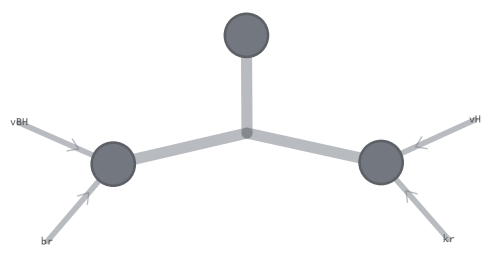

In [82]:
right_eig_out.draw()

In [83]:
right_eig_out

TensorNetwork(tensors=3, indices=5)

In [84]:
diff = (right_eig_out.contract(output_inds=tn_r.contract().inds) - tn_r.contract())

In [85]:
(diff & diff.conj()).contract()

np.complex64(1.2157133e-12+0j)

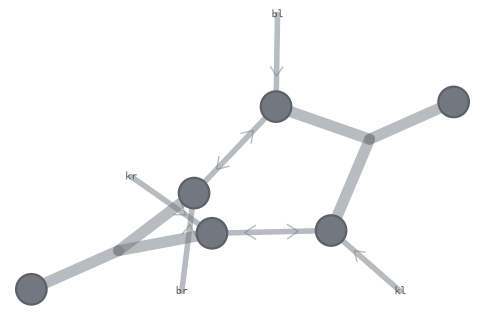

In [86]:
(left_eig_out & right_eig_out).draw()

In [87]:
qu_rho

Tensor(shape=(16, 16, 16, 16), inds=('kl', 'kr', 'bl', 'br'), tags=oset([]))

In [88]:
rho_A_opt_eig = (
    (left_eig_out & right_eig_out)
    .contract(output_inds=rho_A_opt.contract().inds)
)

In [89]:
rho_A_opt_eig

Tensor(shape=(16, 16, 16, 16), inds=('kl', 'kr', 'bl', 'br'), tags=oset([]))

In [90]:
diff_rho_opt_eig = rho_A_opt.contract() - rho_A_opt_eig.contract()

In [91]:
(diff_rho_opt_eig & diff_rho_opt_eig.conj()).contract()

np.complex64(8.3467264e-14+0j)

In [92]:
purified_states = (
    left_eig_out.tensors[0]
    & right_eig_out.tensors[0]
)

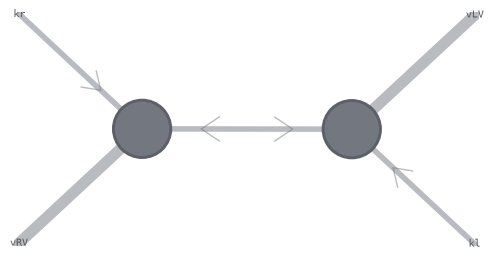

In [93]:
purified_states.draw()

In [94]:
psi_0 = purified_states.isel({'vRV': 0, 'vLV': 0})

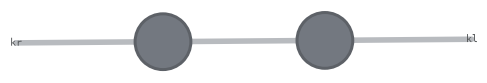

In [95]:
psi_0.draw()

In [96]:
psi_0_norm = (psi_0 & psi_0.conj()).contract()

Fudging this bit a bit, should we expect `psi_0` to be correctly normalised by definition? Ignoring for now and normalizing by hand.

In [97]:
psi_0_norm

np.complex64(0.4414243-4.656613e-09j)

In [98]:
psi_0_norm = np.real(psi_0_norm)

In [99]:
help(psi_0.multiply)

Help on method multiply in module quimb.tensor.tensor_core:

multiply(x, inplace=False, spread_over=8) method of quimb.tensor.tensor_core.TensorNetwork instance
    Scalar multiplication of this tensor network with ``x``.

    Parameters
    ----------
    x : scalar
        The number to multiply this tensor network by.
    inplace : bool, optional
        Whether to perform the multiplication inplace.
    spread_over : int, optional
        How many tensors to try and spread the multiplication over, in
        order that the effect of multiplying by a very large or small
        scalar is not concentrated.



In [100]:
(
    psi_0
    .multiply(
        psi_0_norm**(-0.5),
        inplace=True,
        spread_over=2
    )
)

TensorNetwork(tensors=2, indices=3)

In [101]:
(psi_0 & psi_0.conj()).contract()

np.complex64(1-1.8626451e-09j)

In [102]:
psi_0

TensorNetwork(tensors=2, indices=3)

In [103]:
help(psi_0.tensors[0].unfuse_)

Help on partial in module functools:

functools.partial(<bound method Tensor.unfuse of...inds=('kl', 'vH'), tags=oset([]))>, inplace=True)


In [104]:
psi_0.tensors[0]

Tensor(shape=(16, 16), inds=('kl', 'vH'), tags=oset([]))

In [105]:
(
    psi_0
    .tensors[0]
    .unfuse_(
        unfuse_map={'kl': ['kl1', 'kl2']},
        shape_map={'kl': (4, 4)}
    )
)

Tensor(shape=(4, 4, 16), inds=('kl1', 'kl2', 'vH'), tags=oset([]))

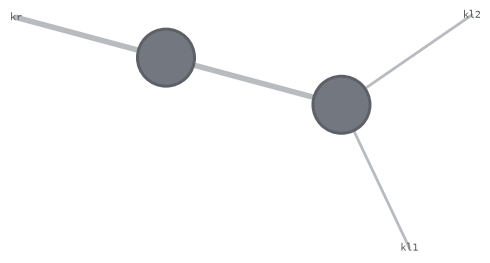

In [106]:
psi_0.draw()

In [107]:
(
    psi_0
    .tensors[1]
    .unfuse_(
        unfuse_map={'kr': ['kr1', 'kr2']},
        shape_map={'kr': (4, 4)}
    )
)

Tensor(shape=(4, 4, 16), inds=('kr1', 'kr2', 'vH'), tags=oset([]))

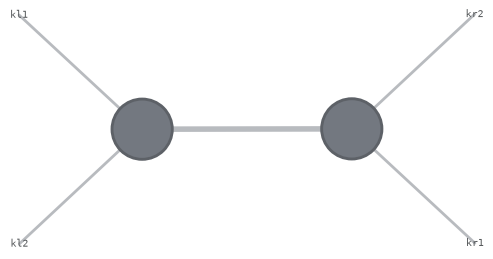

In [108]:
psi_0.draw()

In [109]:
rho_0 = (
    psi_0
    & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
)

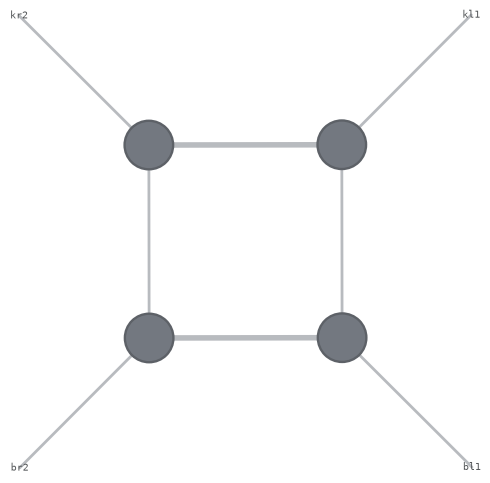

In [110]:
rho_0.draw()

In [111]:
rho_0.contract(inplace=True)

TensorNetwork(tensors=1, indices=4)

In [112]:
rho_0.reindex({'kr2': 'br2', 'kl1': 'bl1'}).contract()

np.complex64(1.0000001-5.015973e-10j)

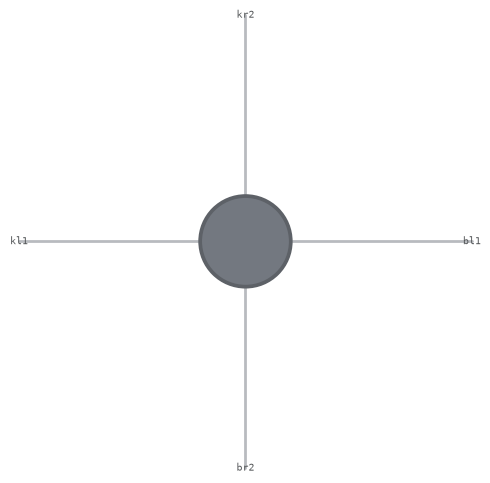

In [113]:
rho_0.draw()

In [114]:
rho_0 = rho_0.tensors[0]

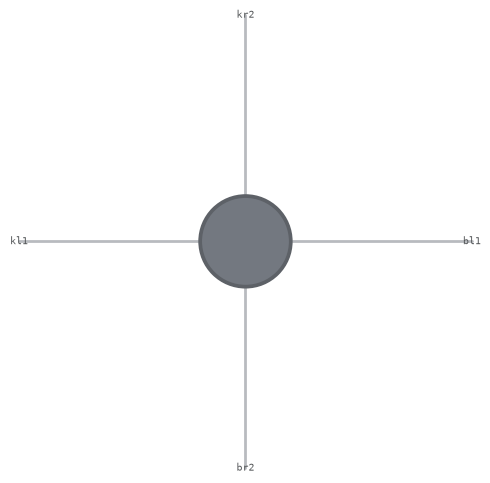

In [115]:
rho_0.draw()

In [116]:
rho_0

Tensor(shape=(4, 4, 4, 4), inds=('kl1', 'kr2', 'bl1', 'br2'), tags=oset([]))

In [117]:
split_rho_0 = qtn.tensor_core.tensor_split(
    rho_0,
    left_inds=['kl1', 'bl1'],
    absorb=None
)

In [118]:
split_rho_0

TensorNetwork(tensors=3, indices=5)

In [119]:
split_rho_0.tensors[1].data

array([5.0552291e-01, 7.2330274e-03, 2.0978353e-03, 1.6347195e-03,
       7.6597859e-04, 5.5747828e-04, 2.0454750e-04, 1.4109716e-04,
       6.4858272e-05, 5.5201421e-05, 1.9521092e-05, 7.4783838e-06,
       1.5195488e-06, 4.1644864e-07, 2.5104521e-07, 4.2951239e-08],
      dtype=float32)

## Compute $E$ and extract defect operators

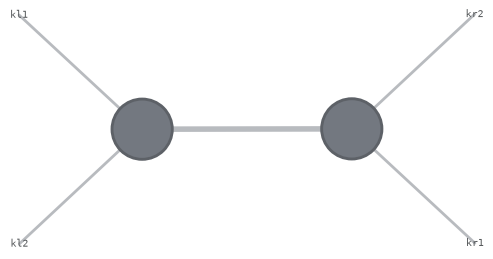

In [120]:
psi_0.draw()

In [121]:
np_X = np.array([
    [0,1],
    [1,0]
])

In [122]:
np_XX = np.kron(np_X, np_X)

In [123]:
np_XX

array([[0, 0, 0, 1],
       [0, 0, 1, 0],
       [0, 1, 0, 0],
       [1, 0, 0, 0]])

In [124]:
qu_XX = qtn.Tensor(
    np_XX,
    inds=['k', 'b']
)

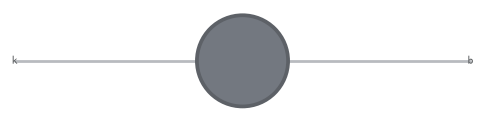

In [125]:
qu_XX.draw()

Let `edm` denote $E$.

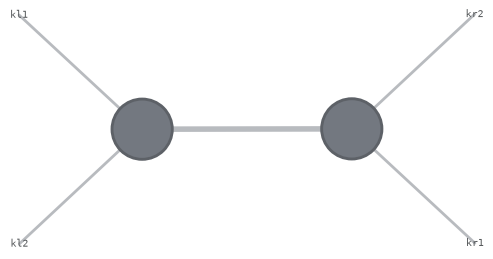

In [126]:
psi_0.draw()

In [127]:
edm = (
    psi_0
    & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
    & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
    & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
    & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
    & psi_0.reindex({
        'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
    })
)

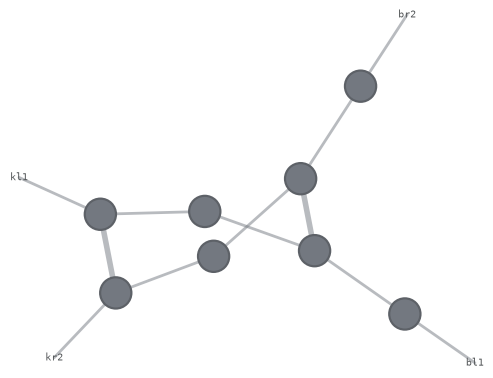

In [128]:
edm.draw()

In [129]:
edm = edm.contract()

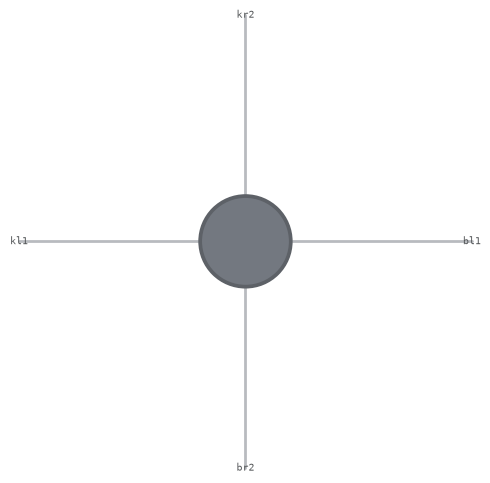

In [130]:
edm.draw()

Take schmidt decomposition

In [131]:
split_edm = qtn.tensor_core.tensor_split(
    edm,
    left_inds=['kl1', 'bl1'],
    absorb=None,
    bond_ind='vH'
)

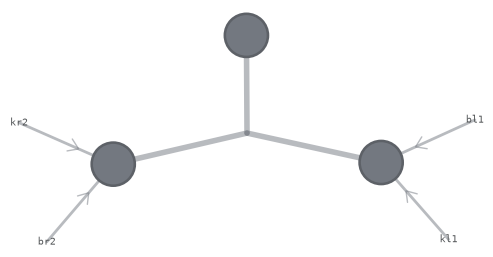

In [132]:
split_edm.draw()

In [133]:
split_edm

TensorNetwork(tensors=3, indices=5)

In [134]:
split_edm.tensors[1].data

array([4.93269178e-01, 7.21203818e-03, 2.15493000e-03, 1.68675734e-03,
       9.51266497e-04, 4.93966944e-04, 1.89009942e-04, 1.49647171e-04,
       5.51130112e-05, 5.38241320e-05, 1.49332123e-05, 1.07347992e-05,
       1.24951680e-06, 9.54930135e-07, 3.67674116e-07, 1.03757246e-07])

In [135]:
split_edm.tensors[0]

Tensor(shape=(4, 4, 16), inds=('kl1', 'bl1', 'vH'), tags=oset([]), left_inds=('kl1', 'bl1'))

In [136]:
split_edm

TensorNetwork(tensors=3, indices=5)

### Left defect operator

In [137]:
left_edm = split_edm.tensors[0].isel({'vH': 0})

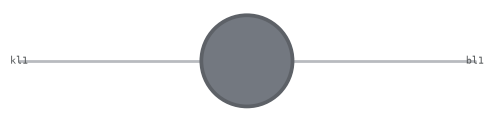

In [138]:
left_edm.draw()

In [139]:
np.round(left_edm.data, 3)

array([[-0.148-0.324j, -0.031+0.017j,  0.254-0.169j, -0.   +0.j   ],
       [ 0.038-0.018j, -0.151-0.31j ,  0.   +0.j   , -0.254+0.169j],
       [ 0.381-0.115j,  0.   +0.j   ,  0.151+0.31j ,  0.031-0.017j],
       [-0.   -0.j   , -0.381+0.115j, -0.038+0.018j,  0.148+0.324j]])

In [140]:
u, s, vh = qtn.tensor_core.tensor_split(
    left_edm,
    left_inds=['kl1'],
    absorb=None,
    bond_ind='v'
)

In [141]:
left_defect_operator = (
    (u & vh)
    .contract()
    .conj()
    .reindex({'kl1': 'bl1', 'bl1': 'kl1'})
)

In [142]:
np.sum(s.data)

np.float64(1.4144355858588418)

In [143]:
s

Tensor(shape=(4,), inds=('v',), tags=oset([]))

In [144]:
left_defect_operator

Tensor(shape=(4, 4), inds=('bl1', 'kl1'), tags=oset([]))

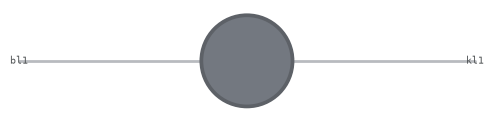

In [145]:
left_defect_operator.draw()

In [146]:
np.round(left_defect_operator.data, 3)

array([[-0.339+0.928j,  0.014-0.007j, -0.152+0.003j, -0.   -0.j   ],
       [ 0.006+0.015j, -0.361+0.92j , -0.   -0.j   ,  0.152-0.003j],
       [ 0.112+0.103j,  0.   -0.j   ,  0.361-0.92j , -0.014+0.007j],
       [ 0.   +0.j   , -0.112-0.103j, -0.006-0.015j,  0.339-0.928j]])

In [147]:
np.abs(np.trace(left_defect_operator.data @ left_edm.data))

np.float64(1.3586508834021134)

### Right defect operator

In [148]:
right_edm = split_edm.tensors[2].isel({'vH': 0})

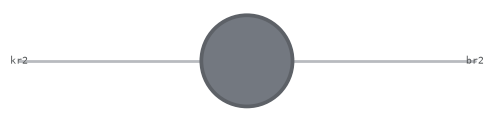

In [149]:
right_edm.draw()

In [150]:
u, s, vh = qtn.tensor_core.tensor_split(
    right_edm,
    left_inds=['kr2'],
    absorb=None,
    bond_ind='v'
)

In [151]:
right_defect_operator = (
    (u & vh)
    .contract()
    .conj()
    .reindex({'kr2': 'br2', 'br2': 'kr2'})
)

In [152]:
np.sum(s.data)

np.float64(1.4144644462068465)

In [153]:
right_defect_operator

Tensor(shape=(4, 4), inds=('br2', 'kr2'), tags=oset([]))

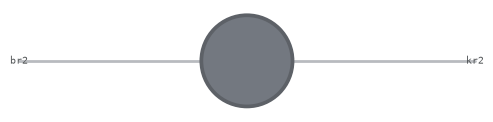

In [154]:
right_defect_operator.draw()

## Compute invariant

In [155]:
rho_0

Tensor(shape=(4, 4, 4, 4), inds=('kl1', 'kr2', 'bl1', 'br2'), tags=oset([]))

In [156]:
rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

In [157]:
rho_0_l

Tensor(shape=(4, 4), inds=('kl1', 'bl1'), tags=oset([]))

In [158]:
qu_XX

Tensor(shape=(4, 4), inds=('k', 'b'), tags=oset([]))

In [159]:
left_defect_op_invariant = (
    rho_0_l
    & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
    & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
    & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
    & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
)

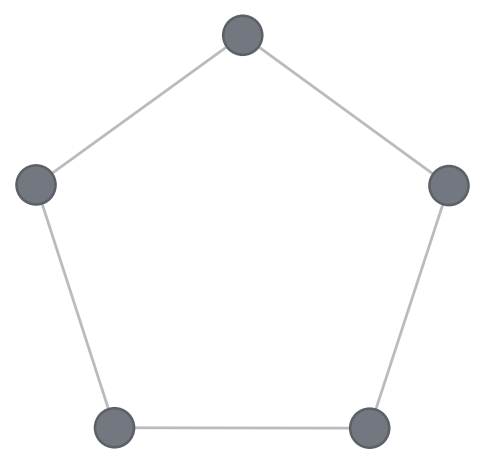

In [160]:
left_defect_op_invariant.draw()

In [161]:
left_defect_op_invariant.contract()

np.complex128(-1.0000001192092893+5.015973192357137e-10j)

In [162]:
rho_0_l

Tensor(shape=(4, 4), inds=('kl1', 'bl1'), tags=oset([]))

In [163]:
np_rho_0_l = rho_0_l.data

In [164]:
help(left_defect_operator.transpose)

Help on method transpose in module quimb.tensor.tensor_core:

transpose(*output_inds, inplace=False) method of quimb.tensor.tensor_core.Tensor instance
    Transpose this tensor - permuting the order of both the data *and*
    the indices. This operation is mainly for ensuring a certain data
    layout since for most operations the specific order of indices doesn't
    matter.

    Note to compute the tranditional 'transpose' of an operator within a
    contraction for example, you would just use reindexing not this.

    Parameters
    ----------
    output_inds : sequence of str
        The desired output sequence of indices.
    inplace : bool, optional
        Perform the tranposition inplace.

    Returns
    -------
    tt : Tensor
        The transposed tensor.

    See Also
    --------
    transpose_like, reindex



In [165]:
np_left_defect_operator = left_defect_operator.transpose('kl1', 'bl1').data

In [166]:
np.trace(
    np_XX
    @ np_left_defect_operator.conj()
    @ np_XX
    @ np_left_defect_operator
    @ np_rho_0_l
)

np.complex128(-1.000000119209289+5.015973403067489e-10j)

In [167]:
np.round(np_left_defect_operator, 3)

array([[-0.339+0.928j,  0.006+0.015j,  0.112+0.103j,  0.   +0.j   ],
       [ 0.014-0.007j, -0.361+0.92j ,  0.   -0.j   , -0.112-0.103j],
       [-0.152+0.003j, -0.   -0.j   ,  0.361-0.92j , -0.006-0.015j],
       [-0.   -0.j   ,  0.152-0.003j, -0.014+0.007j,  0.339-0.928j]])

## Defect operator from density matrix.

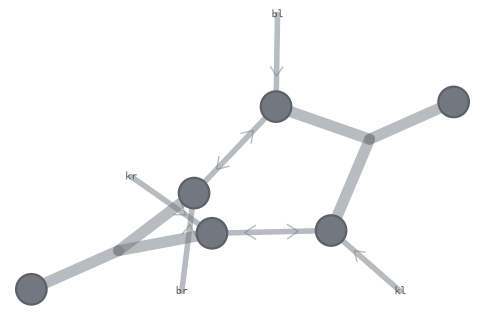

In [168]:
(left_eig_out & right_eig_out).draw()

In [169]:
(left_eig_out & right_eig_out)

TensorNetwork(tensors=6, indices=8)

In [170]:
left_eig_out

TensorNetwork(tensors=3, indices=5)

In [171]:
right_eig_out

TensorNetwork(tensors=3, indices=5)

In [172]:
k_bra_left_eig_out = (
    left_eig_out.tensors[0]
    & left_eig_out.tensors[1]
    & (left_eig_out.tensors[2].conj())
)

k_bra_right_eig_out = (
    right_eig_out.tensors[0]
    & right_eig_out.tensors[1]
    & (right_eig_out.tensors[2].conj())
)

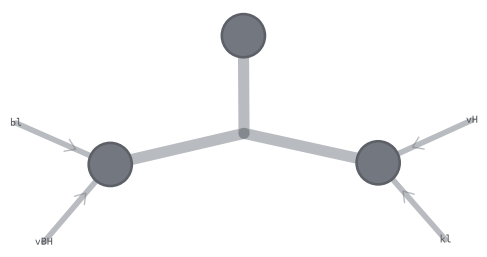

In [173]:
k_bra_left_eig_out.draw()

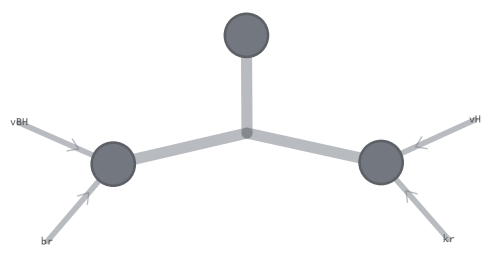

In [174]:
k_bra_right_eig_out.draw()

In [175]:
k_bra_right_eig_out

TensorNetwork(tensors=3, indices=5)

In [176]:
(
    k_bra_left_eig_out
    .tensors[0]
    .unfuse_(
        unfuse_map={'kl': ['kl1', 'kl2']},
        shape_map={'kl': (4, 4)}
    )
)

(
    k_bra_left_eig_out
    .tensors[2]
    .unfuse_(
        unfuse_map={'bl': ['bl1', 'bl2']},
        shape_map={'bl': (4, 4)}
    )
)

(
    k_bra_right_eig_out
    .tensors[0]
    .unfuse_(
        unfuse_map={'kr': ['kr1', 'kr2']},
        shape_map={'kr': (4, 4)}
    )
)

(
    k_bra_right_eig_out
    .tensors[2]
    .unfuse_(
        unfuse_map={'br': ['br1', 'br2']},
        shape_map={'br': (4, 4)}
    )
)

Tensor(shape=(256, 16, 4, 4), inds=('vRV', 'vBH', 'br1', 'br2'), tags=oset([]), left_inds=('vBH', 'br1', 'br2'))

In [177]:
full_edm = (
    k_bra_left_eig_out.reindex({'bl1': 'bbl1', 'bl2': 'bl2'})
    & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
    & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
    & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
    & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
    & k_bra_right_eig_out.reindex({'br1': 'br1', 'br2': 'bbr2'})
)

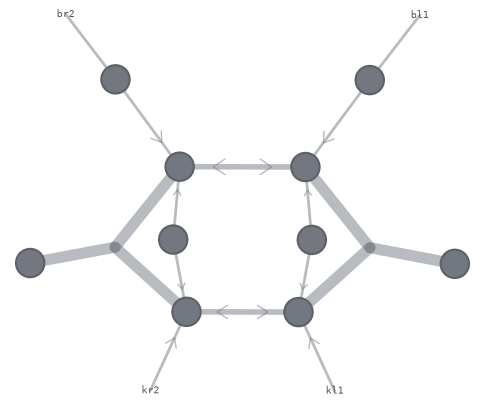

In [178]:
full_edm.draw()

In [179]:
full_edm = full_edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

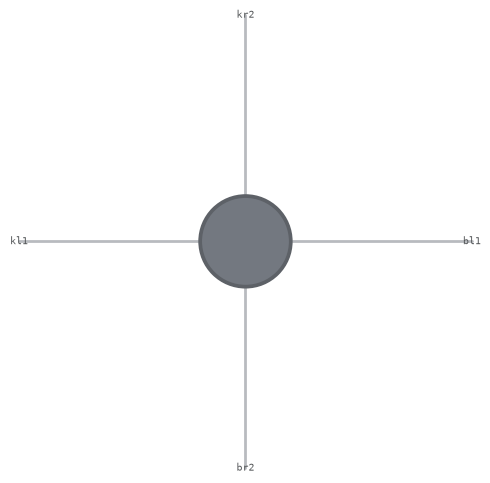

In [180]:
full_edm.draw()

In [181]:
full_edm

Tensor(shape=(4, 4, 4, 4), inds=('kl1', 'kr2', 'bl1', 'br2'), tags=oset([]))

In [182]:
split_full_edm = qtn.tensor_core.tensor_split(
    full_edm,
    left_inds=['kl1', 'bl1'],
    absorb=None,
    bond_ind='vH'
)

In [183]:
split_full_edm.tensors[1].data

array([2.21506328e-01, 3.44651896e-03, 1.33040557e-03, 1.22305841e-03,
       7.44469919e-04, 4.37327290e-04, 3.15276463e-04, 1.57007008e-04,
       1.21025641e-04, 1.13118623e-04, 7.20953089e-05, 4.40462887e-05,
       3.75296442e-05, 1.77977687e-05, 4.76732425e-06, 2.63752907e-06])

In [184]:
left_edm = split_full_edm.tensors[0].isel({'vH': 0})

In [185]:
u, s, vh = qtn.tensor_core.tensor_split(
    left_edm,
    left_inds=['kl1'],
    absorb=None,
    bond_ind='v'
)

In [186]:
left_defect_operator = (
    (u & vh)
    .contract()
    .conj()
    .reindex({'kl1': 'bl1', 'bl1': 'kl1'})
)

In [187]:
np.sum(s.data)

np.float64(1.9996183145256676)

In [188]:
right_edm = split_full_edm.tensors[2].isel({'vH': 0})

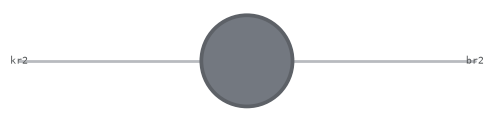

In [189]:
right_edm.draw()

In [190]:
u, s, vh = qtn.tensor_core.tensor_split(
    right_edm,
    left_inds=['kr2'],
    absorb=None,
    bond_ind='v'
)

In [191]:
right_defect_operator = (
    (u & vh)
    .contract()
    .conj()
    .reindex({'kr2': 'br2', 'br2': 'kr2'})
)

In [192]:
np.sum(s.data)

np.float64(1.9900536931749202)

In [193]:
right_defect_operator

Tensor(shape=(4, 4), inds=('br2', 'kr2'), tags=oset([]))

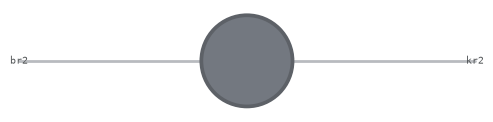

In [194]:
right_defect_operator.draw()

In [195]:
qt_rho

Tensor(shape=(16, 16, 16, 16), inds=('lk', 'rk', 'lb', 'rb'), tags=oset([]))

In [196]:
rho_defect_l = (
    qt_rho
    .reindex({'rk': 'rb'})
    .contract()
    .unfuse_(
        unfuse_map={'lk': ['kl1', 'kl2'], 'lb': ['bl1', 'bl2'],},
        shape_map={'lk': (4, 4), 'lb': (4,4)}
    )
    .reindex({'kl2': 'bl2'})
    .contract()
)   

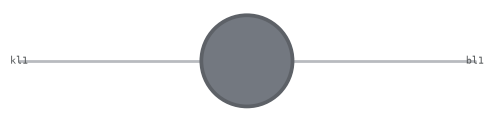

In [197]:
rho_defect_l.draw()

In [198]:
left_defect_op_invariant = (
    rho_defect_l
    & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
    & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
    & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
    & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
)

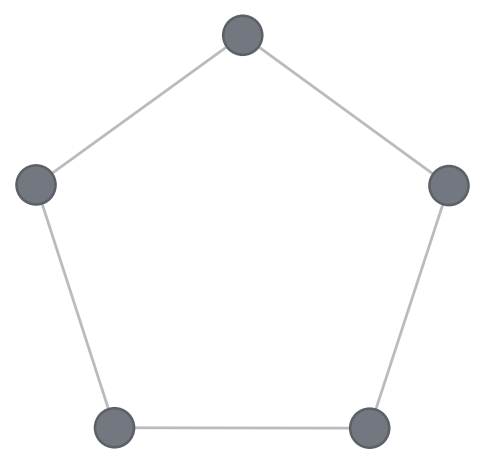

In [199]:
left_defect_op_invariant.draw()

In [200]:
left_defect_op_invariant.contract()

np.complex128(-0.9999999999999871-6.605440694418263e-09j)

# Conclusion
It works! Now tidy up and sweep.